# Mittag-Leffler relaxation

The multiscale relaxation model of

> A. N. Hassani, L. Haris, M. Appel, T. Seydel, A. M. Stadler and G. R. Kneller,
> *Multiscale relaxation dynamics and diffusion of myelin basic protein in solution studied by
> quasielastic neutron scattering*, J. Chem. Phys. **156**, 025102 (2022),
> [doi:10.1063/5.0077100](https://doi.org/10.1063/5.0077100).

Internal protein dynamics does not relax exponentially. It relaxes with a power-law tail, which
reflects a broad distribution of relaxation rates rather than a single one. The paper models that
with a Mittag-Leffler (ML) relaxation function (their Eq. 28)

$$ \phi_{ML}(t) = E_\alpha\left(-(|t|/\tau_R)^\alpha\right), \qquad 0 < \alpha \le 1 $$

which decays as $(t/\tau_R)^{-\alpha}/\Gamma(1-\alpha)$ at long times and becomes a simple
exponential at $\alpha = 1$. For a protein in solution this internal relaxation is multiplied by
the global translational diffusion of the whole molecule (their Eqs. 38-39),

$$ F^{(+)}(t) = e^{-\epsilon|t|}\left(EISF + (1 - EISF)\,\phi_{ML}(|t|)\right),
\qquad \epsilon = \hbar D q^2 $$

and the measured spectrum is its Fourier transform, their Eq. (41):

$$ S^{(+)}(x) = EISF\,\frac{1}{\pi}\frac{\epsilon}{x^2+\epsilon^2}
+ (1 - EISF)\,\tilde{\phi}^{(\epsilon)}_{ML}(|x|). $$

Note that the elastic term is a **Lorentzian of half width $\epsilon$**, not a delta function:
global diffusion broadens it.

EasyDynamics provides this at two levels.

- `DiffusionDampedMittagLeffler` is the quasi-elastic lineshape
  $\tilde{\phi}^{(\epsilon)}_{ML}$ of their Eq. (42), a `ModelComponent` with a free `damping`
  that you can fit however you like.
- `MittagLefflerDiffusion` is the full Eq. (41) across $Q$, a `DiffusionModel` in which
  `damping` is constrained to $\hbar D q^2$ with a single global $D$.

## Two notes on Eq. (42)

The component evaluates Eq. (42) with two deliberate differences from the printed equation.

1. **The printed equation is written for $\tau_R = 1$.** You can see this without any derivation:
   it forms $(\omega^2+\epsilon^2)^\alpha + 1$, and you cannot add a pure number to something
   carrying dimensions of frequency$^{2\alpha}$ unless the frequency is already dimensionless. The
   component evaluates the printed expression at the reduced variables $\omega/\Gamma$ and
   $\epsilon/\Gamma$ and divides by $\Gamma = \hbar/\tau_R$, which restores a general relaxation
   time while leaving the printed expression itself untouched. $\Gamma$ is the component's
   `width`.
2. **The $1/\pi$ prefactor is missing from the printed equation.** Applying the paper's own
   Eq. (40), $\tilde{\phi}^{(\epsilon)} = \frac{1}{\pi}\Re\{\hat{\phi}(\epsilon+i\omega)\}$, to
   the ML Laplace transform of their Eq. (32) reproduces Eq. (42) exactly, prefactor included.
   Without it the lineshape integrates to $\pi$ rather than to 1, which would be inconsistent with
   the normalised elastic term in Eq. (41). It is included here, so `scale` is the integrated area
   of the profile.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import curve_fit

import easydynamics as edyn

%matplotlib widget

## The component

`DiffusionDampedMittagLeffler` has four parameters: `scale` (the integrated area), `alpha` (the
form parameter $\alpha$), `width` (the relaxation rate $\Gamma = \hbar/\tau_R$, as an energy) and
`damping` (the diffusion damping $\epsilon$, also as an energy).

The form parameter is what makes this more than a Lorentzian. At $\alpha = 1$ the relaxation is
exponential and the profile is exactly a Lorentzian of half width at half maximum
`width + damping`. Lowering $\alpha$ broadens the distribution of relaxation rates, which
sharpens the peak and fattens the wings at the same time.

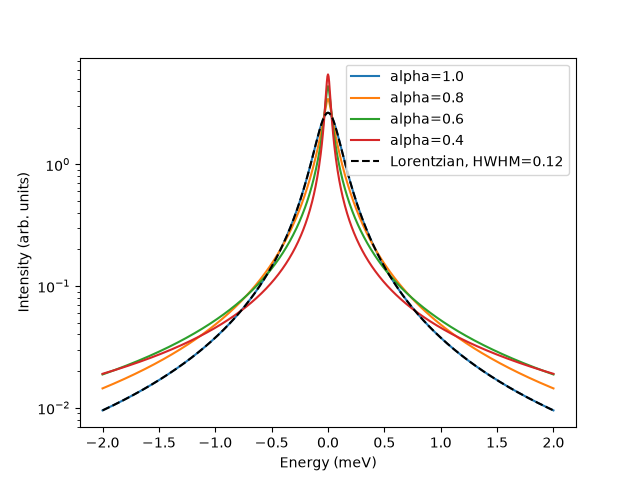

In [2]:
x = np.linspace(-2, 2, 801)

plt.figure()
for alpha in [1.0, 0.8, 0.6, 0.4]:
    mittag_leffler = edyn.DiffusionDampedMittagLeffler(
        display_name=f'alpha={alpha}',
        scale=1.0,
        alpha=alpha,
        width=0.1,
        damping=0.02,
    )
    plt.plot(x, mittag_leffler.evaluate(x), label=mittag_leffler.display_name)

# alpha=1 must be a plain Lorentzian of HWHM width+damping, shown here as a check.
lorentzian = edyn.Lorentzian(display_name='Lorentzian, HWHM=0.12', area=1.0, width=0.12)
plt.plot(x, lorentzian.evaluate(x), 'k--', label=lorentzian.display_name)

plt.yscale('log')
plt.xlabel('Energy (meV)')
plt.ylabel('Intensity (arb. units)')
plt.legend()
plt.show()

`damping` must be strictly positive. It is what keeps the profile finite at zero energy transfer:
without it the ML spectrum diverges as $|\omega|^{\alpha-1}$, as the paper notes below its
Eq. (34). Increasing it broadens the profile without changing its area.

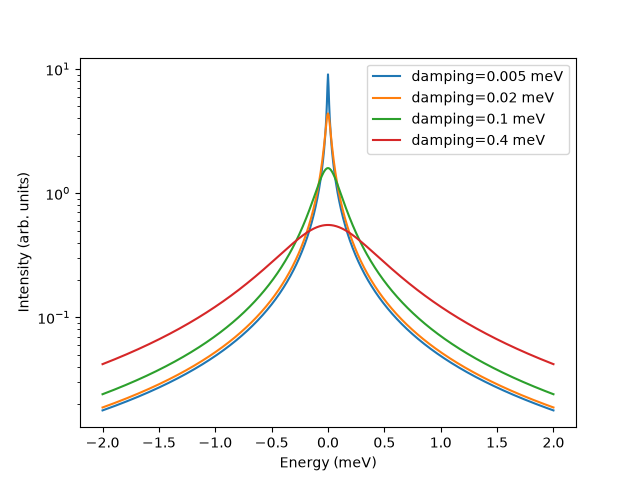

alpha=1.0: area under the curve = 1.0000
alpha=0.6: area under the curve = 1.0000


In [3]:
plt.figure()
for damping in [0.005, 0.02, 0.1, 0.4]:
    mittag_leffler = edyn.DiffusionDampedMittagLeffler(
        scale=1.0, alpha=0.6, width=0.1, damping=damping
    )
    plt.plot(x, mittag_leffler.evaluate(x), label=f'damping={damping} meV')

plt.yscale('log')
plt.xlabel('Energy (meV)')
plt.ylabel('Intensity (arb. units)')
plt.legend()
plt.show()

# The scale parameter is the integrated area. The wings fall off as slowly as |x|**(-1-alpha),
# so this check needs a very wide, logarithmically spaced grid to converge.
half_grid = np.logspace(-5, 9, 30000)
xx = np.concatenate([-half_grid[::-1], half_grid])
for alpha in [1.0, 0.6]:
    mittag_leffler = edyn.DiffusionDampedMittagLeffler(
        scale=1.0, alpha=alpha, width=0.1, damping=0.02
    )
    area = np.trapezoid(mittag_leffler.evaluate(xx), xx)
    print(f'alpha={alpha}: area under the curve = {area:.4f}')

## The diffusion model

`MittagLefflerDiffusion` assembles Eq. (41) at every $Q$: an elastic `Lorentzian` of area
$K\cdot EISF$ and half width $\epsilon = \hbar D q^2$, plus a `DiffusionDampedMittagLeffler` of
scale $K\cdot(1-EISF)$ and the same damping $\epsilon$. The diffusion coefficient $D$ is the
single global parameter that ties the $Q$ values together, exactly as in
`BrownianTranslationalDiffusion`.

The numbers below are those of MBP in $D_2O$ buffer at 283 K: $D = 3.31$ Å²/ns from dynamic light
scattering (Table I of the paper), and a $Q$ range matching IN16B's
0.8 Å⁻¹ < $q$ < 1.8 Å⁻¹.

In [4]:
Q = np.linspace(0.8, 1.8, 6)

# hbar in meV*ps, used to turn a relaxation time in ps into a rate in meV.
HBAR_MEV_PS = 0.6582119569

model = edyn.MittagLefflerDiffusion(
    display_name='MBP in D2O, 283 K',
    scale=1.0,
    diffusion_coefficient=3.31e-11,  # 3.31 A^2/ns, from DLS
    A_0=0.02,
    relaxation_rate=HBAR_MEV_PS / 50.0,  # tau_R = 50 ps
    alpha=0.85,
    Q=Q,
)
print(model)
print(model.get_component_collections()[0].list_component_names())

MittagLefflerDiffusion(display_name=MBP in D2O, 283 K, x_unit=meV, y_unit=dimensionless, 
    diffusion_coefficient=<Parameter 'diffusion_coefficient': 3.310e-11 m^2/s, bounds=[0.0:inf]>, 
    A_0=<Parameter 'A_0': 0.0200, bounds=[0.0:1.0]>, A_1=<Parameter 'A_1': 0.9800, bounds=[0.0:1.0]>, 
    relaxation_rate=<Parameter 'relaxation_rate': 0.0132 meV, bounds=[1e-10:inf]>, 
    alpha=<Parameter 'alpha': 0.8500, bounds=[1e-10:1.0]>, 
    scale=<Parameter 'scale': 1.0000 meV, bounds=[0.0:inf]>)
['Elastic Lorentzian', 'Mittag-Leffler']


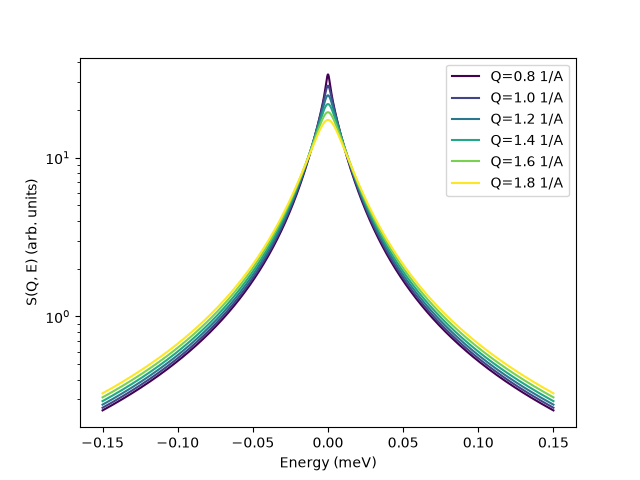

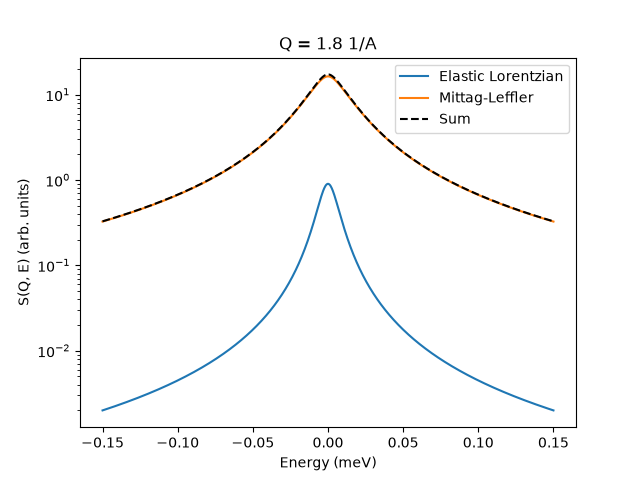

In [5]:
energy = np.linspace(-0.15, 0.15, 1201)
collections = model.get_component_collections()
cmap = plt.cm.viridis

plt.figure()
for i, collection in enumerate(collections):
    plt.plot(
        energy,
        collection.evaluate(energy),
        color=cmap(i / (len(collections) - 1)),
        label=f'Q={Q[i]:.1f} 1/A',
    )
plt.yscale('log')
plt.xlabel('Energy (meV)')
plt.ylabel('S(Q, E) (arb. units)')
plt.legend()
plt.show()

# The two components at a single Q: the elastic Lorentzian and the Mittag-Leffler term.
plt.figure()
collection = collections[-1]
for name in collection.list_component_names():
    plt.plot(energy, collection.evaluate_component(energy, name), label=name)
plt.plot(energy, collection.evaluate(energy), 'k--', label='Sum')
plt.yscale('log')
plt.xlabel('Energy (meV)')
plt.ylabel('S(Q, E) (arb. units)')
plt.title(f'Q = {Q[-1]:.1f} 1/A')
plt.legend()
plt.show()

The damping $\epsilon = \hbar D q^2$ is shared by both components by construction, and it is what
`calculate_width` returns. At these $Q$ values it is a few µeV, comparable with IN16B's 3.5 µeV
resolution — which is exactly the difficulty the paper describes: the slow relaxation modes
overlap with the elastic line and with global diffusion.

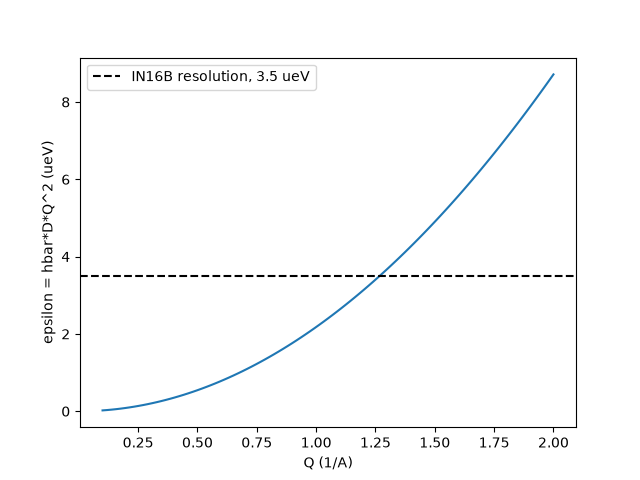

epsilon =  1.394 ueV | Lorentzian width =  1.394 ueV | ML damping =  1.394 ueV
epsilon =  2.179 ueV | Lorentzian width =  2.179 ueV | ML damping =  2.179 ueV
epsilon =  3.137 ueV | Lorentzian width =  3.137 ueV | ML damping =  3.137 ueV
epsilon =  4.270 ueV | Lorentzian width =  4.270 ueV | ML damping =  4.270 ueV
epsilon =  5.577 ueV | Lorentzian width =  5.577 ueV | ML damping =  5.577 ueV
epsilon =  7.059 ueV | Lorentzian width =  7.059 ueV | ML damping =  7.059 ueV


In [6]:
Q_fine = np.linspace(0.1, 2.0, 101)

plt.figure()
plt.plot(Q_fine, model.calculate_width(Q_fine) * 1e3)
plt.xlabel('Q (1/A)')
plt.ylabel('epsilon = hbar*D*Q^2 (ueV)')
plt.axhline(3.5, color='k', linestyle='dashed', label='IN16B resolution, 3.5 ueV')
plt.legend()
plt.show()

for collection, epsilon in zip(collections, model.calculate_width(), strict=True):
    print(
        f'epsilon = {epsilon * 1e3:6.3f} ueV | '
        f'Lorentzian width = {collection[0].width.value * 1e3:6.3f} ueV | '
        f'ML damping = {collection[1].damping.value * 1e3:6.3f} ueV'
    )

### Parameters that vary with Q

In the paper only $D$ is global. The relaxation time $\tau$, the form parameter $\alpha$ and the
EISF are all fitted **independently at each $q$** (their Fig. 5). Pass `allow_Q_variation` to get
that: each $Q$ then owns its own parameters, while $D$ and the overall scale stay shared.

In [7]:
model_per_Q = edyn.MittagLefflerDiffusion(
    display_name='MBP in D2O, 283 K, per-Q parameters',
    scale=1.0,
    diffusion_coefficient=3.31e-11,
    A_0=0.02,
    relaxation_rate=HBAR_MEV_PS / 50.0,
    alpha=0.85,
    allow_Q_variation={'A_0': True, 'relaxation_rate': True, 'alpha': True},
    Q=Q,
)

print('Global parameters :', [p.name for p in model_per_Q.get_global_variables()])
print('Free parameters   :', len(model_per_Q.get_free_parameters()))

Global parameters : ['scale', 'diffusion_coefficient']
Free parameters   : 20


The paper does not tabulate the fitted $\tau(q)$, $\alpha(q)$ and $EISF(q)$ — they appear only as
plots in its Fig. 5. The values used below are therefore **indicative**, read off that figure for
MBP in $D_2O$ at 283 K, and are here only to show the machinery and the trends the paper
describes: $\tau$ falls with $q$ because higher $q$ probes more localised and faster motion, while
$\alpha$ rises towards 1 because localised motion relaxes more nearly exponentially.

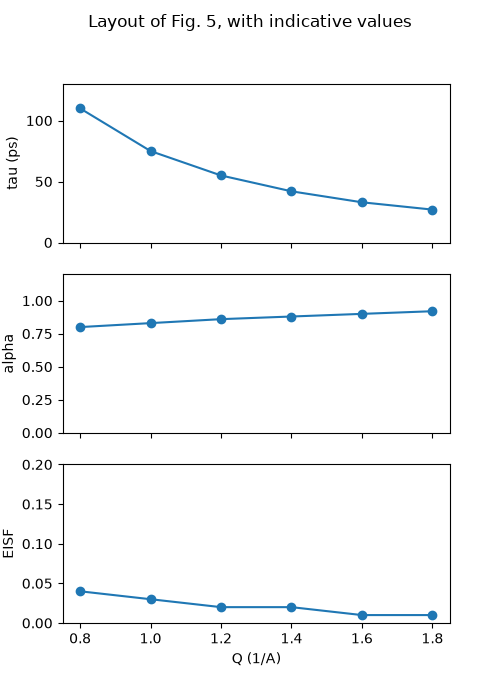

In [8]:
# Indicative values read off Fig. 5 of the paper; not published numbers.
tau_ps = np.array([110.0, 75.0, 55.0, 42.0, 33.0, 27.0])
alpha_per_Q = np.array([0.80, 0.83, 0.86, 0.88, 0.90, 0.92])
eisf_per_Q = np.array([0.04, 0.03, 0.02, 0.02, 0.01, 0.01])

for i in range(len(Q)):
    model_per_Q._relaxation_rate_list[i].value = HBAR_MEV_PS / tau_ps[i]  # ruff: ignore[private-member-access]
    model_per_Q._alpha_list[i].value = alpha_per_Q[i]  # ruff: ignore[private-member-access]
    model_per_Q._A_0_list[i].value = eisf_per_Q[i]  # ruff: ignore[private-member-access]

fig, axes = plt.subplots(3, 1, sharex=True, figsize=(5, 7))
axes[0].plot(Q, HBAR_MEV_PS / model_per_Q.calculate_relaxation_rate(), 'o-')
axes[0].set_ylabel('tau (ps)')
axes[0].set_ylim(0, 130)
axes[1].plot(Q, model_per_Q.calculate_alpha(), 'o-')
axes[1].set_ylabel('alpha')
axes[1].set_ylim(0, 1.2)
axes[2].plot(Q, model_per_Q.calculate_EISF(), 'o-')
axes[2].set_ylabel('EISF')
axes[2].set_ylim(0, 0.2)
axes[2].set_xlabel('Q (1/A)')
fig.suptitle('Layout of Fig. 5, with indicative values')
plt.show()

## Comparing with the paper

Most of the figures in the paper cannot be reproduced from the paper alone.

- **Figs. 1 and 2** show measured spectra and intermediate scattering functions. They need the raw
  IN16B data, which lives at [doi.ill.fr/10.5291/ILL-DATA.8-04-874](http://doi.ill.fr/10.5291/ILL-DATA.8-04-874).
- **Fig. 4** shows circular dichroism results, which are not tabulated.
- **Figs. 5 and 6** are built from the per-$q$ fit parameters, which are only ever shown as plots.
  The layout of Fig. 5 is reproduced above and Fig. 6 below, but with indicative parameters rather
  than the published ones.

Two figures *are* reproducible from what the paper publishes, and both are done below from the
library's own code: the **Arrhenius plot of Fig. 3** from the diffusion coefficients in Table I,
and the **energy barrier distribution of Fig. 7** from the closed-form Eq. (48).

### Fig. 3, left panel: Arrhenius plot of the diffusion coefficient

Table I of the paper lists the diffusion coefficients measured by dynamic light scattering for
both solvents. Fitting $D(T) = D_0 e^{-\Delta G / k_B T}$ (their Eq. 44) to them recovers the
activation energies quoted in the text. MBP coagulates at 323 K in pure $D_2O$, so the paper
replaces the measured 0.31 Å²/ns there by the value extrapolated from lower temperatures, and so
do we.

MBP D2O     : fitted dG = 5.10 kcal/mol (paper quotes 5.10)
MBP 30% TFE : fitted dG = 6.05 kcal/mol (paper quotes 6.05)


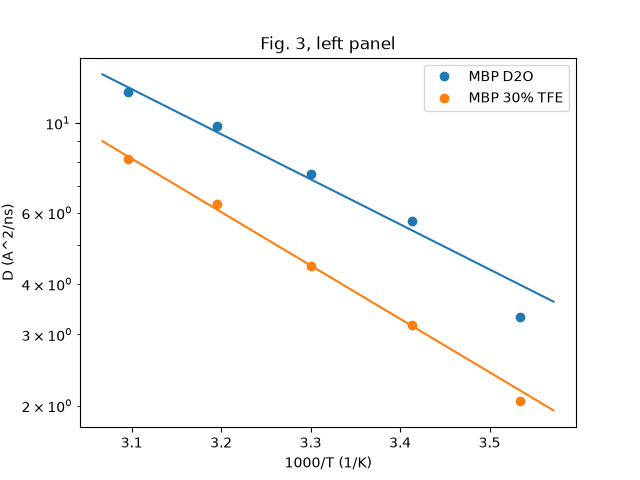

In [9]:
# Table I of Hassani et al. (2022). D_DLS in A^2/ns.
temperature = np.array([283.0, 293.0, 303.0, 313.0, 323.0])
D_D2O = np.array([3.31, 5.72, 7.49, 9.85, 11.94])  # 323 K: extrapolated, MBP coagulates
D_TFE = np.array([2.05, 3.17, 4.42, 6.32, 8.15])

BOLTZMANN_KCAL = 1.987204259e-3  # kcal/(mol*K)


def arrhenius(T: np.ndarray, D_0: float, delta_G: float) -> np.ndarray:
    """Eq. (44): D(T) = D_0 exp(-dG / kB T), with dG in kcal/mol."""
    return D_0 * np.exp(-delta_G / (BOLTZMANN_KCAL * T))


plt.figure()
T_fine = np.linspace(280.0, 326.0, 200)
for label, D, colour, quoted in [
    ('MBP D2O', D_D2O, 'tab:blue', 5.10),
    ('MBP 30% TFE', D_TFE, 'tab:orange', 6.05),
]:
    (D_0, delta_G), _ = curve_fit(arrhenius, temperature, D, p0=[1e5, 5.0])
    plt.plot(1000.0 / temperature, D, 'o', color=colour, label=label)
    plt.plot(1000.0 / T_fine, arrhenius(T_fine, D_0, delta_G), '-', color=colour)
    print(f'{label:12s}: fitted dG = {delta_G:.2f} kcal/mol (paper quotes {quoted:.2f})')

plt.yscale('log')
plt.xlabel('1000/T (1/K)')
plt.ylabel('D (A^2/ns)')
plt.legend()
plt.title('Fig. 3, left panel')
plt.show()

Both activation energies come out at the values quoted in the paper, 5.10 and 6.05 kcal/mol. Note
that Eq. (44) has to be fitted to $D$ itself rather than to $\ln D$: least squares on the
logarithm weights the low-temperature points much more heavily and gives 5.69 and 6.28 kcal/mol
instead.

### Fig. 7, right panel: the distribution of energy barriers

Reading the ML relaxation as diffusion in Zwanzig's rough harmonic potential, the paper derives a
distribution of dimensionless barrier heights $h = \Delta E / k_B T$ (their Eq. 48),

$$ P_{ML}(h) = \frac{2h\sin(\pi\alpha)}
{\pi\left(e^{-\alpha h^2} + e^{\alpha h^2} + 2\cos(\pi\alpha)\right)}. $$

This is a closed form in $h$ and $\alpha$ only, so it reproduces exactly. As $\alpha \to 1$ it
collapses onto $\delta(h)$ — a smooth potential with no barriers — and as $\alpha \to 0$ it
broadens to include arbitrarily high ones. That is the physical reading of the form parameter:
**a smaller $\alpha$ means a rougher energy landscape.**

/home/runner/work/dynamics-lib/dynamics-lib/src/easydynamics/sample_model/diffusion_model/mittag_leffler_diffusion.py:671: RuntimeWarning: invalid value encountered in divide
  return numerator / denominator


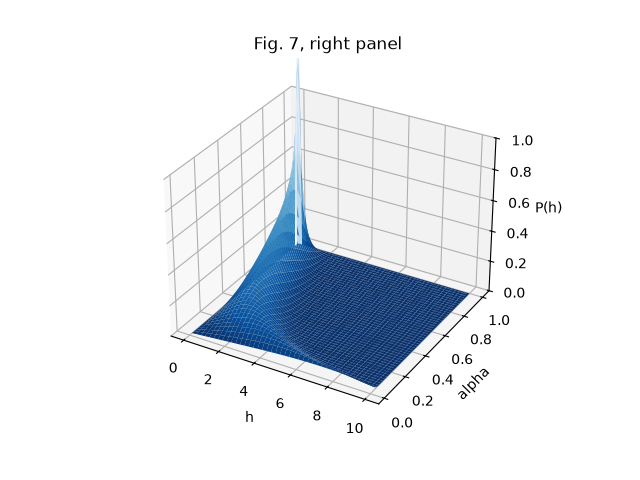

In [10]:
h = np.linspace(0.0, 10.0, 201)
alpha_grid = np.linspace(0.02, 1.0, 100)

barrier_model = edyn.MittagLefflerDiffusion(Q=np.array([1.0]))
distribution = np.empty((alpha_grid.size, h.size))
for i, alpha in enumerate(alpha_grid):
    barrier_model.alpha = alpha
    distribution[i] = barrier_model.calculate_energy_barrier_distribution(h)[0]

fig = plt.figure()
ax = fig.add_subplot(projection='3d')
H, A = np.meshgrid(h, alpha_grid)
ax.plot_surface(H, A, distribution, cmap='Blues_r', linewidth=0, antialiased=True)
ax.set_xlabel('h')
ax.set_ylabel('alpha')
ax.set_zlabel('P(h)')
ax.set_zlim(0, 1)
ax.set_title('Fig. 7, right panel')
plt.show()

### Fig. 6: relaxation rate spectra

The same model has a closed-form distribution of relaxation *rates* (their Eq. 37),

$$ p_{ML}(\lambda) = \frac{\sin(\pi\alpha)}
{\pi\lambda\left((\lambda\tau_R)^{-\alpha} + (\lambda\tau_R)^{\alpha} + 2\cos(\pi\alpha)\right)}, $$

which is what the paper plots against $q$ in its Fig. 6. It depends on the fitted $\tau(q)$ and
$\alpha(q)$, so the surface below uses the indicative values set above rather than the published
ones. The trend the paper reports is nevertheless the one that shows: as $q$ grows the peak moves
to higher rates and the distribution narrows, because $\alpha$ approaches 1.

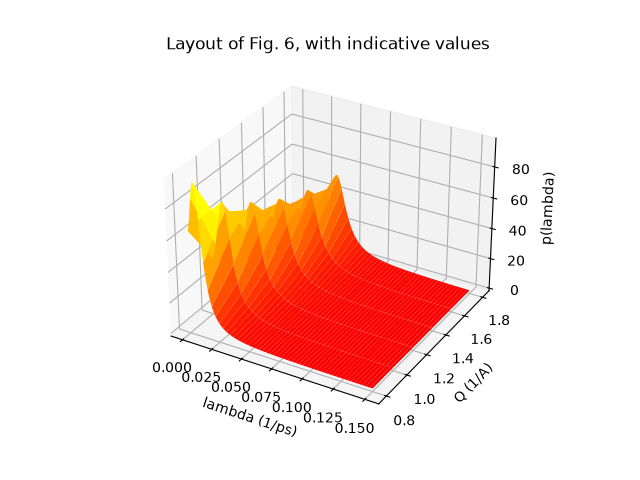

In [11]:
# lambda in 1/ps, converted to the model's meV via hbar.
rate_per_ps = np.linspace(0.001, 0.15, 200)
spectrum = model_per_Q.calculate_relaxation_rate_spectrum(rate_per_ps * HBAR_MEV_PS)

fig = plt.figure()
ax = fig.add_subplot(projection='3d')
RATE, QQ = np.meshgrid(rate_per_ps, Q)
ax.plot_surface(RATE, QQ, spectrum, cmap='autumn', linewidth=0, antialiased=True)
ax.set_xlabel('lambda (1/ps)')
ax.set_ylabel('Q (1/A)')
ax.set_zlabel('p(lambda)')
ax.set_title('Layout of Fig. 6, with indicative values')
plt.show()